## Imports & Loads

In [1]:
CANVAS_SIZE = (440, 440)

In [2]:
from PIL import Image, ImageOps
def resize_image(image: Image):
    if len(image.getbands()) == 1:
        PADDING_COLOR = 0  # Single integer for grayscale/depth maps
    else:
        PADDING_COLOR = (0, 0, 0)  # Tuple for RGB images
    return ImageOps.pad(image, CANVAS_SIZE, color=PADDING_COLOR)

In [3]:
from transformers import pipeline
import os
import matplotlib.pyplot as plt

c:\Users\Simon\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
depth_estimator = pipeline(
    "depth-estimation",
    model="Intel/dpt-hybrid-midas",
    api_key=os.environ["HF_TOKEN"]
)

Loading weights: 100%|██████████| 414/414 [00:00<00:00, 8540.90it/s]


In [5]:
from ultralytics import YOLO
model = YOLO("stroke_generation/yolo11x-seg.pt")

## Image Pre-loading

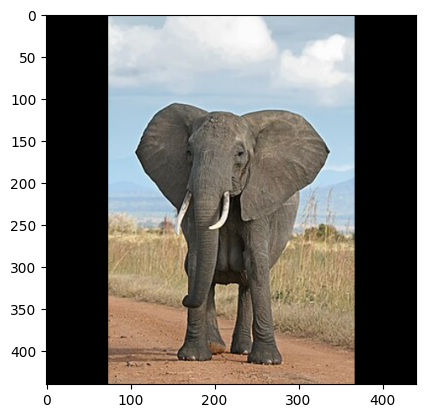

In [6]:
import numpy as np
from PIL import Image, ImageOps, ImageFilter  # Added ImageFilter
from skimage.segmentation import slic
import matplotlib.pyplot as plt

# 1. Load your PIL image
pil_original_image = Image.open("C:/Users/Simon/Documents/projecten/paint-bot/images/elephant.jpg")

# 2. Resize to 440x440 (assuming resize_image is defined elsewhere)
pil_resized_image = resize_image(pil_original_image)

# GaussianBlur takes a 'radius' parameter. Higher radius = more blur.
pil_blurred_image = pil_resized_image.filter(ImageFilter.GaussianBlur(radius=5))
# np_resized_blurred_image = np.array(pil_blurred_image)

# 3. Convert the original resized PIL image to a NumPy array (if still needed)
np_resized_image = np.array(pil_resized_image)
np_original_image = np.array(pil_original_image)

# Display the blurred image to verify
plt.imshow(np_resized_image)
plt.show()

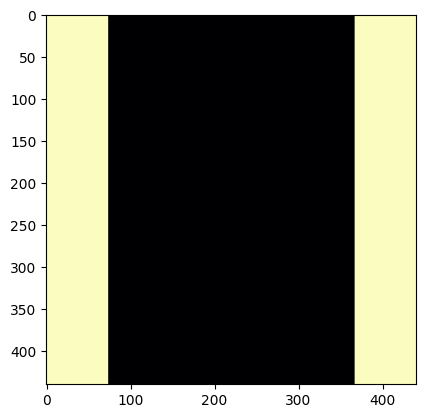

In [7]:
# 3. Create a "dummy" pure white image of the exact same original size
# This represents our "real pixels" mask BEFORE padding
mask_canvas = Image.new("L", pil_original_image.size, color=255)

# 4. Apply the exact same padding transformation to the mask canvas
# ImageOps.pad will scale and pad this mask identically to the elephant image
padded_mask_resized = ImageOps.pad(mask_canvas, CANVAS_SIZE, color=0)
np_padded_mask_resized = np.array(padded_mask_resized)

# 5. Convert mask to a 1 and 0 NumPy array
# Wherever the padded_mask is 255 (white), it's a real pixel (1). Otherwise, it's 0.
padding_mask = (np.array(padded_mask_resized) == 0).astype(np.uint8)
plt.imshow(padding_mask, cmap='magma')
plt.show()

## Depth map

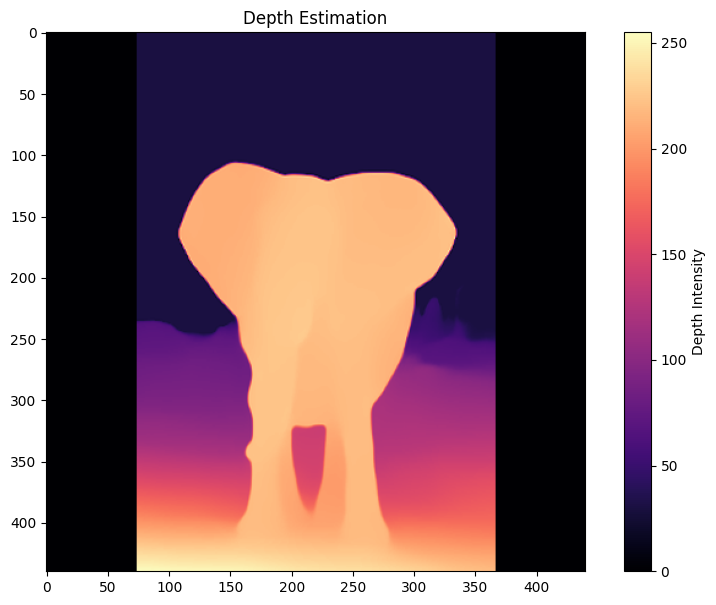

In [8]:
# Pass the original PIL image to the depth estimator
depth_prediction = depth_estimator(pil_original_image)

# Extract the depth map as a numpy array
depth_map_pil = depth_prediction["depth"]
resized_depth_map = np.array(resize_image ( depth_map_pil) )

fig, ax1 = plt.subplots(1, 1, figsize=(10, 7)) # Adjusted 20x7 to 10x7 so a single plot isn't stretched too wide
ax1.set_title("Depth Estimation")
im = ax1.imshow(resized_depth_map, cmap="magma")
fig.colorbar(im, ax=ax1, label="Depth Intensity")
plt.show()

## Segmentation

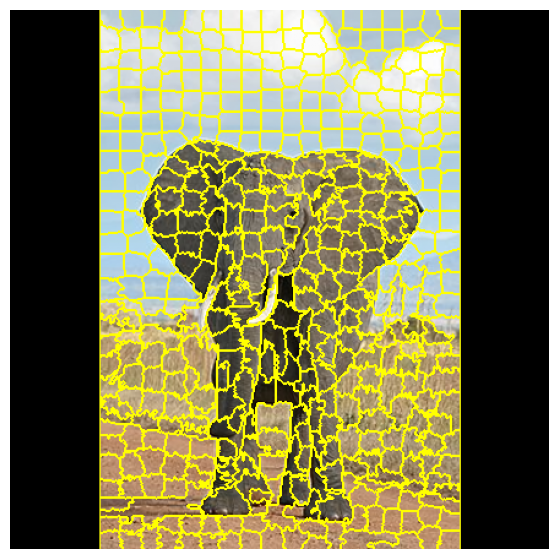

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import center_of_mass
from skimage.segmentation import mark_boundaries
from PIL import Image

# 1. Run SLIC on the original image as you did
# 1. Run SLIC on the original image as you did
segments = slic(
    np_original_image,
    n_segments=500,
    compactness=10
)

# 2. Cast to int32 so PIL can handle it, then resize using Nearest Neighbor
segments_int32 = segments.astype(np.int32) # <--- Added this line
segments_pil = Image.fromarray(segments_int32)

resized_segments_pil = ImageOps.pad(
    segments_pil, 
    CANVAS_SIZE, 
    method=Image.Resampling.NEAREST, 
    color=0
)
resized_segments = np.array(resized_segments_pil)


# 3. Calculate centroids on the NEW resized segments
for label in np.unique(resized_segments):
    # Mask out the background padding (label 0 might contain padding now)
    if label == 0: 
        continue
    centroid = center_of_mass(resized_segments == label)

# 4. Plot using the ALREADY resized/padded elephant image from your previous step
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.imshow(mark_boundaries(np_resized_image, resized_segments)) # 'image' is your 440x440 padded np array
# ax.setTitle("1. Resized SLIC Superpixel Segments", fontsize=14, fontweight='bold')
ax.axis("off")
plt.show()

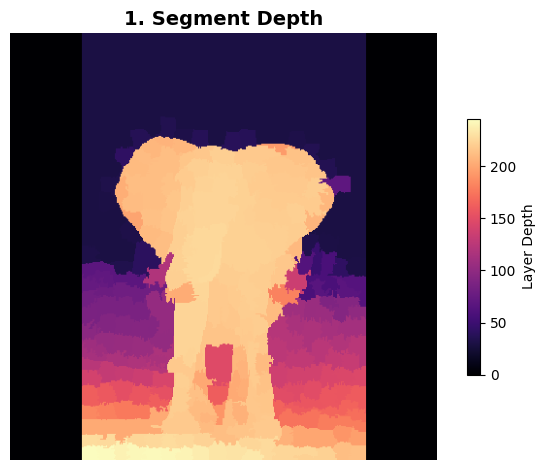

In [10]:
binned_depth_visualization = np.zeros_like(resized_segments, dtype=np.float32)

segment_labels = np.unique(segments)
segment_depths = []

for label in segment_labels:
    mask = (resized_segments == label)

    mean_depth = resized_depth_map[mask].mean()
    
    # Fill the entire segment region with its average depth value
    binned_depth_visualization[mask] = mean_depth

    segment_depths.append((label, mean_depth))

segment_depths.sort(key=lambda x: x[1], reverse=False) # sort segments

fig, ax = plt.subplots(1, 1)

im2 = ax.imshow(binned_depth_visualization, cmap="magma")
ax.set_title("1. Segment Depth", fontsize=14, fontweight='bold')
ax.axis("off")
fig.colorbar(im2, ax=ax, shrink=0.6, label="Layer Depth")

plt.tight_layout()
plt.show()

## Saliency

In [11]:
from saliency import generate_clean_saliency

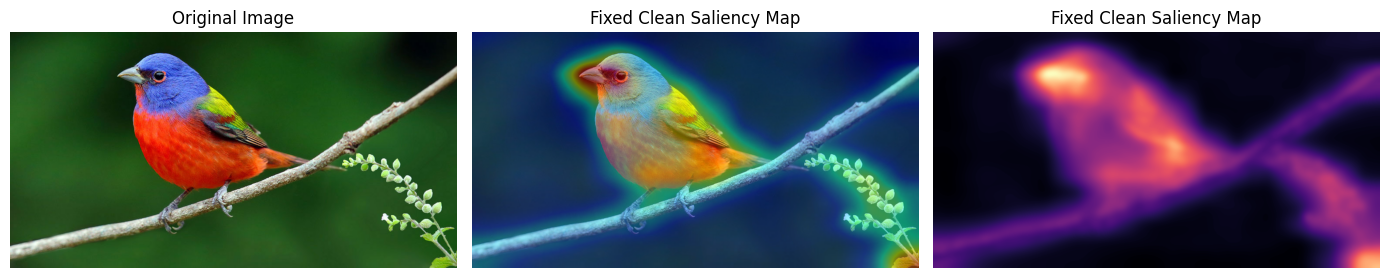

In [12]:
import cv2
import matplotlib.pyplot as plt

image_path = "../images/bird.jpg"
raw_img = Image.open(image_path).convert("RGB")

blurred_saliency, img_cv = generate_clean_saliency(raw_img)

# Color map generation
heatmap_color = cv2.applyColorMap(blurred_saliency, cv2.COLORMAP_JET)

# Overlay with original image
output_img = cv2.addWeighted(img_cv, 0.6, heatmap_color, 0.4, 0)
output_img = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)

# ==========================================
# 3. DISPLAY RESULTS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(14, 7))
axes[0].imshow(raw_img)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(output_img)
axes[1].set_title("Fixed Clean Saliency Map")
axes[1].axis("off")

axes[2].imshow(blurred_saliency, cmap="magma")
axes[2].set_title("Fixed Clean Saliency Map")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## K-nearest

In [13]:
import numpy as np
from PIL import Image
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def extract_dominant_colors(pil_original_image, num_colors=5):
    """
    Extracts the most dominant colors from an image using K-Means clustering.
    
    Parameters:
    - image_path: Str, path to the input image.
    - num_colors: Int, the number of top colors you want to extract.
    """
    # 1. Load the image using PIL
    
    # 2. Optional: Resize image to speed up processing significantly
    # Small dimensions still preserve the overall color palette perfectly
    pil_original_image.thumbnail((150, 150))
    
    # 3. Convert image to RGB (handles RGBA or grayscale conversions) and NumPy array
    img_rgb = pil_original_image.convert("RGB")
    np_img = np.array(img_rgb)
    
    # 4. Reshape the 3D array (Height, Width, Channels) to a 2D array of pixels (N, 3)
    # Each row will represent a single pixel's R, G, B values
    pixels = np_img.reshape(-1, 3)
    
    # 5. Apply K-Means clustering to find the dominant color centers
    # 'n_init="auto"' optimizes starting positions for speed
    kmeans = KMeans(n_clusters=num_colors, n_init="auto", random_state=42)
    kmeans.fit(pixels)
    
    # 6. Get the RGB values of the cluster centers (rounded to integers)
    dominant_colors = kmeans.cluster_centers_.astype(int)
    
    # 7. Calculate the percentage of pixels that belong to each cluster
    labels = kmeans.labels_
    counts = np.bincount(labels)
    percentages = counts / len(pixels)
    
    # 8. Sort colors from most frequent to least frequent
    sort_indices = np.argsort(percentages)[::-1]
    sorted_colors = dominant_colors[sort_indices]
    sorted_percentages = percentages[sort_indices]
    
    return sorted_colors, sorted_percentages

Top 10 Dominant Colors:
-----------------------------------
Color 1: RGB (np.int64(181), np.int64(204), np.int64(220)) | HEX #b5ccdc | (21.0%)
Color 2: RGB (np.int64(182), np.int64(147), np.int64(112)) | HEX #b69370 | (18.1%)
Color 3: RGB (np.int64(125), np.int64(112), np.int64(96)) | HEX #7d7060 | (12.2%)
Color 4: RGB (np.int64(210), np.int64(219), np.int64(225)) | HEX #d2dbe1 | (10.1%)
Color 5: RGB (np.int64(155), np.int64(132), np.int64(104)) | HEX #9b8468 | (9.0%)
Color 6: RGB (np.int64(99), np.int64(90), np.int64(78)) | HEX #635a4e | (7.9%)
Color 7: RGB (np.int64(69), np.int64(66), np.int64(59)) | HEX #45423b | (7.4%)
Color 8: RGB (np.int64(240), np.int64(241), np.int64(241)) | HEX #f0f1f1 | (6.0%)
Color 9: RGB (np.int64(192), np.int64(173), np.int64(140)) | HEX #c0ad8c | (4.3%)
Color 10: RGB (np.int64(41), np.int64(38), np.int64(30)) | HEX #29261e | (3.9%)


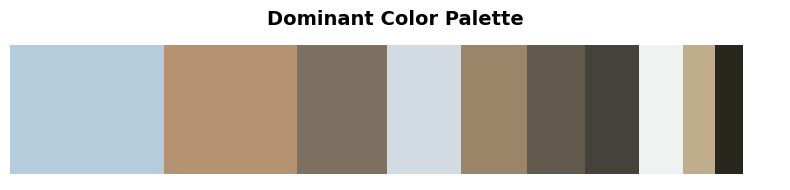

In [14]:
NUMBER_OF_COLORS = 10

colors, percentages = extract_dominant_colors(pil_original_image, num_colors=NUMBER_OF_COLORS)

print(f"Top {NUMBER_OF_COLORS} Dominant Colors:")
print("-" * 35)
for i, (color, pct) in enumerate(zip(colors, percentages), 1):
    hex_color = '#{:02x}{:02x}{:02x}'.format(*color)
    print(f"Color {i}: RGB {tuple(color)} | HEX {hex_color} | ({pct*100:.1f}%)")
    
# Display the visual color palette bar
fig, ax = plt.subplots(figsize=(8, 2))
    
# Hide axes
ax.axis('off')

# Cumulative sum of percentages to stack the bars side-by-side
start = 0
for color, pct in zip(colors, percentages):
    # Normalize RGB to 0-1 range for matplotlib
    normalized_color = color / 255.0
    
    # Plot each color block proportional to its presence
    ax.barh(0, pct, left=start, color=normalized_color, edgecolor='none')
    start += pct
    
plt.title("Dominant Color Palette", fontsize=14, weight='bold', pad=10)
plt.tight_layout()
plt.show()

## Stroke Generation

In [15]:
import numpy as np
from scipy.ndimage import gaussian_filter
import cv2  # Used strictly for footprint tracking on the internal mask
from datatypes import StrokePath, StrokeSequence

def generate_strokes_for_layer(stroke_sequence, resized_segments, label, image, grad, coverage_mask,
                               stroke_generation_stats,
                               max_stroke_list_length=60, min_stroke_length_pixels=10, error_threshold=50, target_coverage=0.90, brush_size = None,
                               max_attempts=100, min_coverage_score=.15,
    ):
    """
    Generates curved robot toolpaths, dynamically seeding multiple strokes within 
    each superpixel until the specified target coverage percentage is met.
    """

    H, W, _ = image.shape

    gy, gx = grad
    segment_mask = (resized_segments == label)
    total_sp_pixels = np.sum(segment_mask)
    
    if total_sp_pixels < 5:
        stroke_generation_stats.count("superpixel too small")
        raise RuntimeError("Superpixel too small.")
        
    # Local coverage loop for this specific superpixel
    attempts = 0
    niceness = 0
    while attempts < max_attempts:
        niceness = min(1, attempts / (max_attempts)) # 0 -> 1

        # Calculate what % of this superpixel is currently covered
        covered_sp_pixels = np.sum(segment_mask & coverage_mask)
        current_coverage = covered_sp_pixels / total_sp_pixels
        
        # Stop spawning new strokes in this patch if we reached our target fill rate
        if current_coverage >= target_coverage:
            stroke_generation_stats.count("coverage already reached")
            return # OK
            
        # Find all pixels in the superpixel that are still bare/unpainted
        unpainted_indices = np.argwhere(segment_mask & ~coverage_mask)
        if len(unpainted_indices) == 0:
            stroke_generation_stats.count("all indices painted")
            return
            
        # For the first attempt, use the true center. For subsequent passes, 
        # pick the middle of the remaining unpainted clusters.
        if attempts == 0:
            cy, cx = np.mean(np.argwhere(segment_mask), axis=0)
        else:
            cy, cx = unpainted_indices[len(unpainted_indices) // 2]
            
        start_x_idx = int(np.clip(cx, 0, W - 1))
        start_y_idx = int(np.clip(cy, 0, H - 1))
        
        stroke_color = image[start_y_idx, start_x_idx]
        path = [(start_x_idx, start_y_idx)]
        
        curr_x, curr_y = float(start_x_idx), float(start_y_idx)
        last_dx, last_dy = 0.0, 0.0
        
        # Trace the curved line
        for _ in range(max_stroke_list_length):
            map_y, map_x = int(np.clip(curr_y, 0, H - 1)), int(np.clip(curr_x, 0, W - 1))
            
            gx_val = gx[map_y, map_x]
            gy_val = gy[map_y, map_x]
            
            dx, dy = -gy_val, gx_val
            mag = np.sqrt(dx**2 + dy**2)
            
            if mag == 0:
                if last_dx == 0 and last_dy == 0: 
                    stroke_generation_stats.count("magnitude 0")
                    break
                dx, dy = last_dx, last_dy
            else:
                dx, dy = dx / mag, dy / mag
                
            if len(path) > 1 and (dx * last_dx + dy * last_dy) < 0:
                dx, dy = -dx, -dy
                
            step_size = 3.0
            next_x = curr_x + dx * step_size
            next_y = curr_y + dy * step_size
            
            next_x_idx = int(np.clip(next_x, 0, W - 1))
            next_y_idx = int(np.clip(next_y, 0, H - 1))
            
            if next_x_idx == map_x and next_y_idx == map_y:
                stroke_generation_stats.count("flat gradient")
                break
                
            # Color threshold boundary limit check
            color_diff = np.linalg.norm(image[next_y_idx, next_x_idx] - stroke_color)
            error_factor = (1+1.2*niceness)
            if color_diff > error_threshold*error_factor:
                stroke_generation_stats.count("too much color error")
                break
                
            path.append((next_x_idx, next_y_idx))
            curr_x, curr_y = next_x, next_y
            last_dx, last_dy = dx, dy

        path_np = np.array(path)

        # Calculate the differences between consecutive points
        # dx = x[1] - x[0], dy = y[1] - y[0]
        distances = np.diff(path_np, axis=0)

        # Calculate Euclidean distance for each segment: sqrt(dx^2 + dy^2)
        segment_lengths = np.sqrt(np.sum(distances**2, axis=1))

        # Sum them up to get the total stroke length
        stroke_length_pixels = np.sum(segment_lengths)
        
        length_factor = max(.1, 1 - 2*niceness)
        if stroke_length_pixels >= min_stroke_length_pixels * length_factor:
            # Convert path to an array structure cv2.polylines expects
            pts = np.array(path, dtype=np.int32).reshape((-1, 1, 2))
            
            # Draw the footprint of this stroke onto our layer mask tracker
            stroke_buffer = np.zeros((H, W), dtype=np.uint8)
            cv2.polylines(stroke_buffer, [pts], isClosed=False, color=255, thickness=brush_size)

            # Create a boolean mask for the current stroke
            current_stroke_mask = (stroke_buffer > 0)

            # 1. Over-painted area: Pixels in the current stroke that were ALREADY covered
            over_painted_mask = current_stroke_mask & coverage_mask
            over_painted_area = np.sum(over_painted_mask)

            # 2. Newly painted area: Pixels in the current stroke that were NOT previously covered
            newly_painted_mask = current_stroke_mask & ~coverage_mask
            newly_painted_area = np.sum(newly_painted_mask)

            # Give a score to this new stroke
            total_painted_area = newly_painted_area + over_painted_area
            if total_painted_area == 0:
                coverage_mask[start_y_idx, start_x_idx] = True
                stroke_generation_stats.count("no painted area")
                attempts += 1
                continue
            
            coverage_score = newly_painted_area / total_painted_area
            if coverage_score <= min_coverage_score:
                coverage_mask[start_y_idx, start_x_idx] = True
                attempts += 1
                stroke_generation_stats.count("coverage score too low")
                continue
            
            # Absorb this footprint into our main coverage layer mask
            coverage_mask = coverage_mask | current_stroke_mask
            
            # Append the validated stroke to the sequence
            processed_color = stroke_color.tolist() if isinstance(stroke_color, np.ndarray) else stroke_color
            processed_color = tuple(int(c) for c in processed_color)
            
            stroke_sequence.strokes.append(StrokePath(
                color=processed_color,
                path=path,
                brushWidth=brush_size,
            ))
        else:
            # If the stroke was rejected for being too short, we mark the initial seed point 
            # as 'painted' in our tracking array anyway.
            stroke_generation_stats.count("stroke too short")
            coverage_mask[start_y_idx, start_x_idx] = True
            attempts += 1
            continue
    stroke_generation_stats.count("max attempts reached")

Precompute the gradient

In [16]:
# 1. Smooth the image to get a reliable, non-noisy gradient field
if np_resized_image.ndim == 3:
    gray = 0.299 * np_resized_image[:,:,0] + 0.587 * np_resized_image[:,:,1] + 0.114 * np_resized_image[:,:,2]
else:
    gray = np_resized_image.copy()

W, H, _ = np_resized_image.shape

gray_smoothed = gaussian_filter(gray, sigma=1.5)
gy, gx = np.gradient(gray_smoothed)

440 440


100%|██████████| 427/427 [01:01<00:00,  6.91it/s]


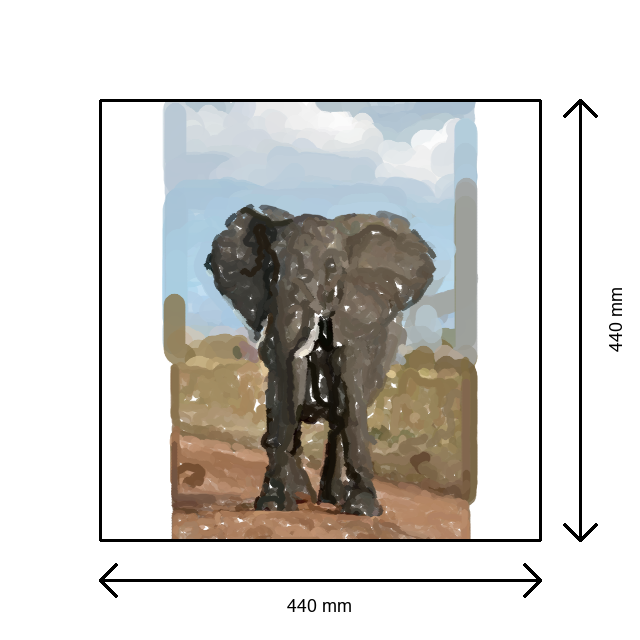

In [17]:
from visualisation import visualize_stroke_sequence
from datatypes import StrokeSequence
from tqdm import tqdm # progress bar
from stroke_generation_stats import StrokeGenerationStats

stroke_generation_stats = StrokeGenerationStats()

H, W, _ = np_resized_image.shape

print(H, W)

stroke_sequence = StrokeSequence(image_size=(W, H))
coverage_mask = ~np_padded_mask_resized

layer_settings = {
    0: {
        "brush_size": 10*2,
        "min_stroke_length_pixels": 120,
        "error_threshold": 150
    },
    80: {
        "brush_size": 3*2,
        "min_stroke_length_pixels": 30,
        "error_threshold": 100
    },
    200: {
        "brush_size": 2*2,
        "min_stroke_length_pixels": 20,
        "error_threshold": 90,
        "target_coverage": 0.95,
        "max_attempts": 200,
        "min_coverage_score": .10
    },
}

# Sort the depth thresholds ascendingly to easily find the correct bracket
sorted_thresholds = sorted(layer_settings.keys())

# Loop through the targeted depth layer bins (Back-to-Front ordering)
for label, mean_depth in tqdm(segment_depths):
    ## Choose brush-size
    # TODO: based on saliency map
    # Find the applicable setting bracket based on mean_depth
    applicable_threshold = 0
    for threshold in sorted_thresholds:
        if mean_depth >= threshold:
            applicable_threshold = threshold
        else:
            break # Since it's sorted, we can stop checking higher thresholds
            
    # Extract the base configurations dictionary
    settings = layer_settings[applicable_threshold]

    # Call the updated stroke generator function using dictionary unpacking (**)
    generate_strokes_for_layer(
        grad=(gy, gx),
        stroke_sequence=stroke_sequence, 
        resized_segments=resized_segments, 
        label=label, 
        image=np_resized_image, 
        stroke_generation_stats=stroke_generation_stats,
        coverage_mask=coverage_mask,
        **settings # Unpacks brush_size, min_stroke_length_pixels, error_threshold dynamically
    )
    
visualize_stroke_sequence(stroke_sequence)

## Stroke Statistics
We counted the reason for a stroke to be declined.
Now, we will create a graph to visualize this.

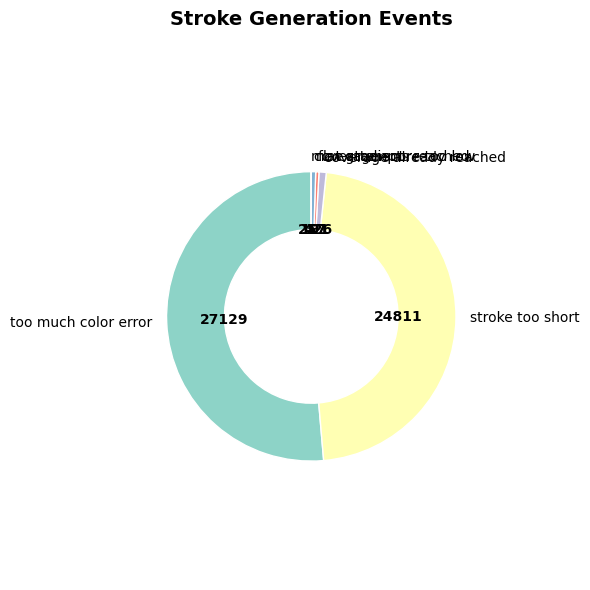

In [18]:
stroke_generation_stats.plot()

Create a video from the strokes.

In [19]:
# from visualisation import animate_stroke_sequence

# animate_stroke_sequence(stroke_sequence)

Save the strokes to a json file.

In [20]:
stroke_sequence.save_to_json("data/my_stroke_sequence.json")